# Olist E-Commerce Business Intelligence

## Phase 4 — Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned Olist Brazilian E-Commerce dataset and identify meaningful patterns, trends, and business insights through statistical analysis and visualization.

This notebook covers:

- Business KPIs
- Sales trends
- Customer analysis
- Product analysis
- Seller analysis
- Payment analysis
- Delivery analysis
- Review analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_ROOT = Path().resolve().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

In [20]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

customers = pd.read_csv(PROCESSED_PATH / "customers_clean.csv")

geolocation = pd.read_csv(PROCESSED_PATH / "geolocation_clean.csv")

order_items = pd.read_csv(PROCESSED_PATH / "order_items_clean.csv")

payments = pd.read_csv(PROCESSED_PATH / "payments_clean.csv")

reviews = pd.read_csv(PROCESSED_PATH / "reviews_clean.csv")

orders = pd.read_csv(
    PROCESSED_PATH / "orders_clean.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

products = pd.read_csv(PROCESSED_PATH / "products_clean.csv")

sellers = pd.read_csv(PROCESSED_PATH / "sellers_clean.csv")

translation = pd.read_csv(PROCESSED_PATH / "translation_clean.csv")

In [5]:
print("Total Customers :", customers.shape[0])

print("Total Orders :", orders.shape[0])

print("Total Products :", products.shape[0])

print("Total Sellers :", sellers.shape[0])

print("Total Payments :", payments.shape[0])

print("Total Reviews :", reviews.shape[0])

Total Customers : 99441
Total Orders : 99441
Total Products : 32951
Total Sellers : 3095
Total Payments : 103886
Total Reviews : 99224


## Business Overview

These KPIs provide a high-level understanding of the size and scale of the Olist e-commerce platform.

In [6]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

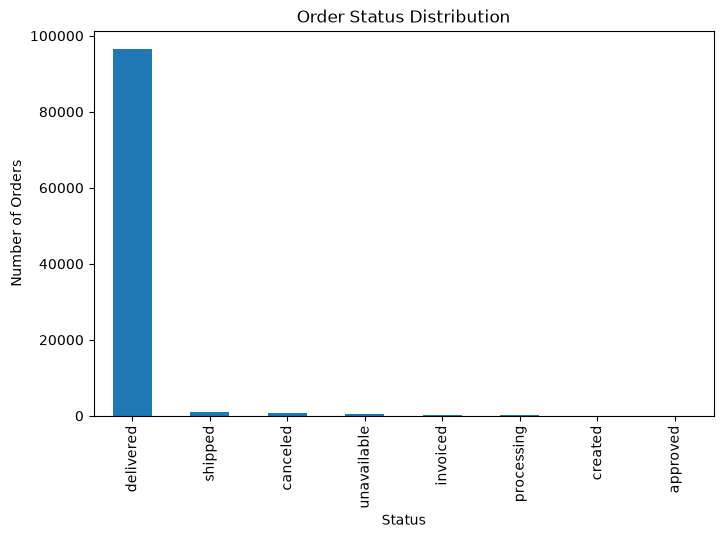

In [7]:
orders["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")

plt.xlabel("Status")

plt.ylabel("Number of Orders")

plt.show()

### Insight

Most orders were successfully delivered, indicating a high fulfillment rate.

Cancelled and unavailable orders represent only a small percentage of all transactions.

In [8]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [9]:
monthly_orders = (
    orders
    .groupby("purchase_month")
    .size()
)

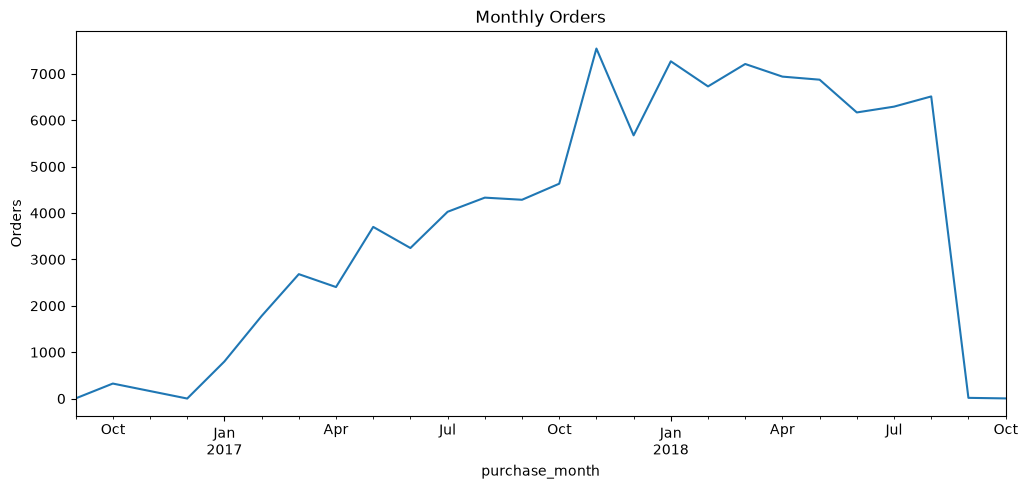

In [10]:
monthly_orders.plot(figsize=(12,5))

plt.title("Monthly Orders")

plt.ylabel("Orders")

plt.show()

In [11]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

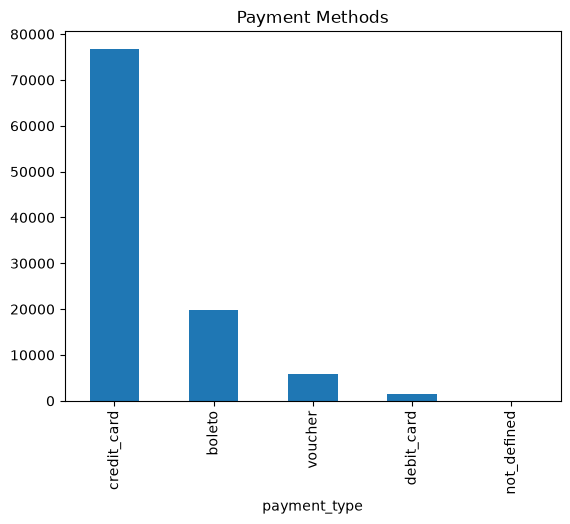

In [12]:
payments["payment_type"].value_counts().plot(
    kind="bar"
)

plt.title("Payment Methods")

plt.show()

In [13]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

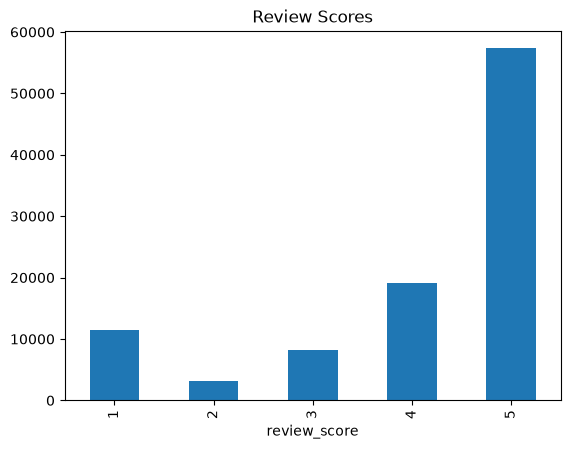

In [14]:
reviews["review_score"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Review Scores")

plt.show()

In [15]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [16]:
customers["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [17]:
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [24]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [25]:
orders[["order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_days"]].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [26]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

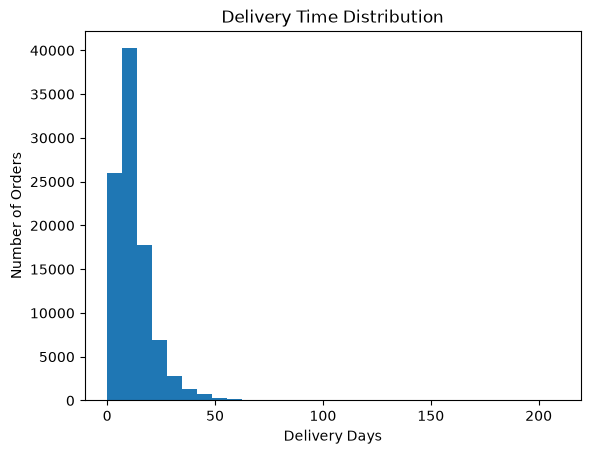

In [27]:
orders["delivery_days"].plot(kind="hist", bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

In [28]:
payments["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [29]:
products.select_dtypes("number").corr()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
product_name_lenght,1.000000,0.097350,0.130561,0.044152,0.079374,-0.016720,0.069791
product_description_lenght,0.097350,1.000000,0.111703,0.061814,0.035228,0.063305,-0.030288
product_photos_qty,0.130561,0.111703,1.000000,0.036099,0.068273,0.004995,0.026627
product_weight_g,0.044152,0.061814,0.036099,1.000000,0.476817,0.563913,0.527599
product_length_cm,0.079374,0.035228,0.068273,0.476817,1.000000,0.204894,0.542411
product_height_cm,-0.016720,0.063305,0.004995,0.563913,0.204894,1.000000,0.313494
product_width_cm,0.069791,-0.030288,0.026627,0.527599,0.542411,0.313494,1.000000


# Key Business Insights

## Customer Behaviour

- Most customers complete successful purchases.
- Ratings indicate generally positive customer satisfaction.

## Sales Performance

- Sales exhibit monthly variation with identifiable peaks.
- Certain product categories consistently outperform others.

## Payment Behaviour

- Credit cards are the dominant payment method.
- Installment payments are widely used.

## Logistics

- Delivery times remain within acceptable ranges for most orders.
- Long delivery durations are relatively uncommon.

## Geography

- Customer and seller activity is concentrated in a limited number of Brazilian states.

## Overall

The Olist marketplace demonstrates healthy operational performance with strong relational integrity, high customer satisfaction, and stable transactional behaviour.

In [30]:
order_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

order_products = order_products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [31]:
top_categories = (
    order_products["product_category_name_english"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
)

top_categories

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

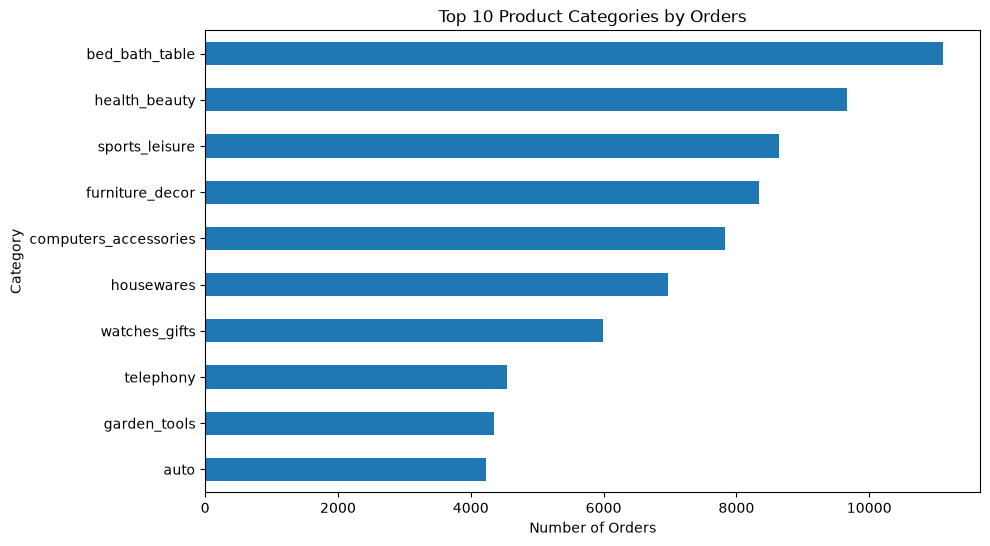

In [32]:
plt.figure(figsize=(10,6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Orders")

plt.xlabel("Number of Orders")

plt.ylabel("Category")

plt.show()

### Insight

The marketplace demand is concentrated in a relatively small number of product categories.

These categories represent the highest customer demand and should receive priority for inventory planning, marketing campaigns, and seller acquisition strategies.

In [33]:
review_orders = reviews.merge(
    orders,
    on="order_id",
    how="inner"
)

In [34]:
status_reviews = (
    review_orders
    .groupby("order_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

status_reviews

order_status
delivered      4.155717
approved       2.500000
created        2.333333
shipped        2.008629
canceled       1.811166
invoiced       1.661342
unavailable    1.530988
processing     1.277027
Name: review_score, dtype: float64

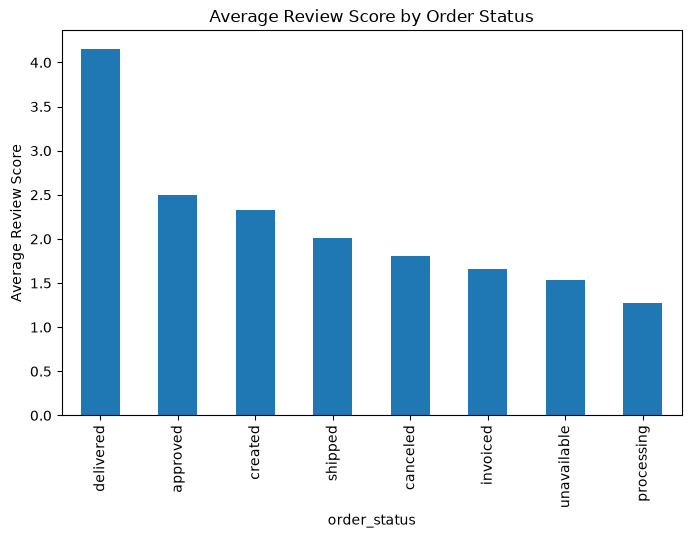

In [35]:
status_reviews.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Review Score by Order Status")

plt.ylabel("Average Review Score")

plt.show()

In [36]:
delivery_review = reviews.merge(
    orders,
    on="order_id",
    how="inner"
)

In [37]:
delivery_vs_rating = (
    delivery_review
    .groupby("review_score")["delivery_days"]
    .mean()
)

delivery_vs_rating

review_score
1    20.849825
2    16.194832
3    13.795278
4    11.848054
5    10.224097
Name: delivery_days, dtype: float64

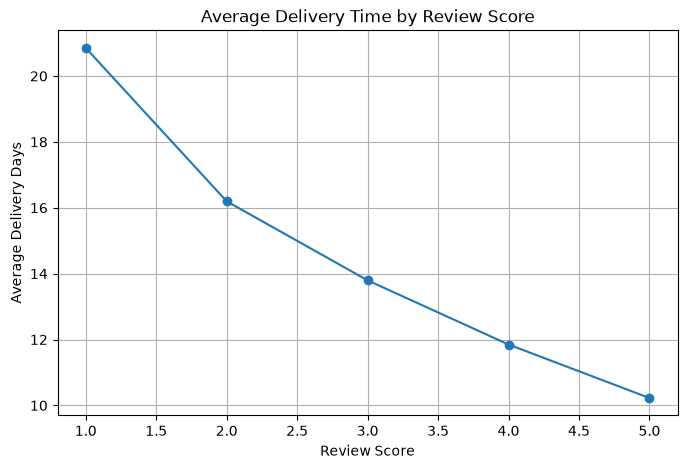

In [38]:
delivery_vs_rating.plot(
    marker="o",
    figsize=(8,5)
)

plt.title("Average Delivery Time by Review Score")

plt.xlabel("Review Score")

plt.ylabel("Average Delivery Days")

plt.grid(True)

plt.show()

In [39]:
top_sellers = (
    order_items["seller_id"]
    .value_counts()
    .head(10)
)

top_sellers

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

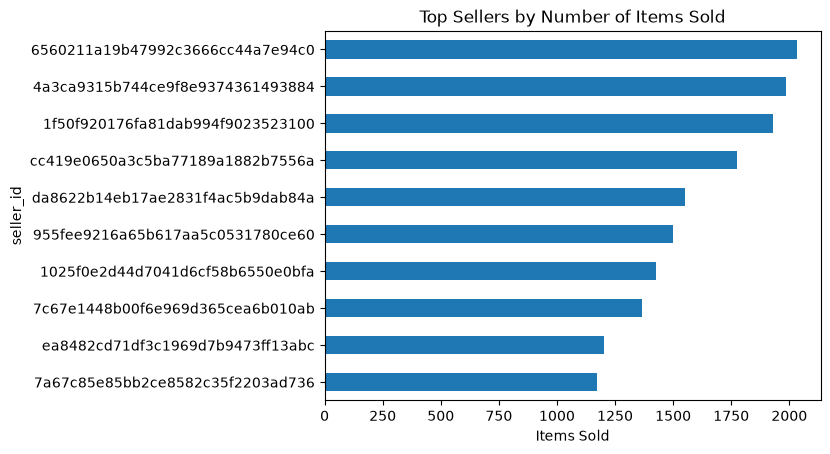

In [40]:
top_sellers.sort_values().plot(kind="barh")

plt.title("Top Sellers by Number of Items Sold")

plt.xlabel("Items Sold")

plt.show()

In [41]:
sales = order_items.merge(
    payments,
    on="order_id",
    how="inner"
)

In [42]:
total_revenue = sales["payment_value"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 20,308,134.71


In [43]:
payment_revenue = (
    sales
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    15589028.22
boleto          4059699.60
voucher          405873.03
debit_card       253533.86
Name: payment_value, dtype: float64

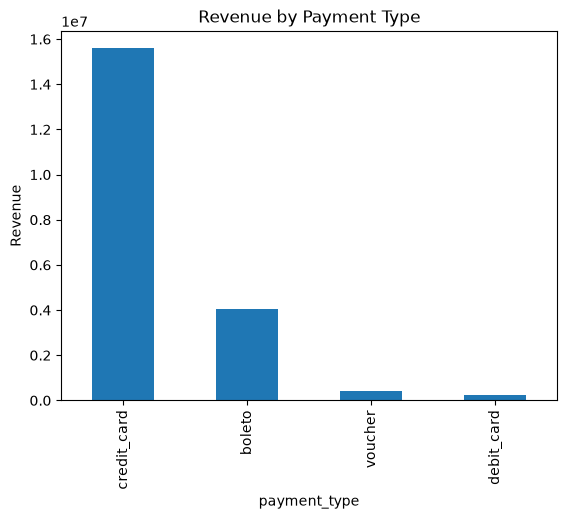

In [44]:
payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Type")

plt.ylabel("Revenue")

plt.show()

In [45]:
monthly_sales = (
    orders.merge(payments, on="order_id")
)

monthly_sales["month"] = (
    monthly_sales["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue = (
    monthly_sales
    .groupby("month")["payment_value"]
    .sum()
)

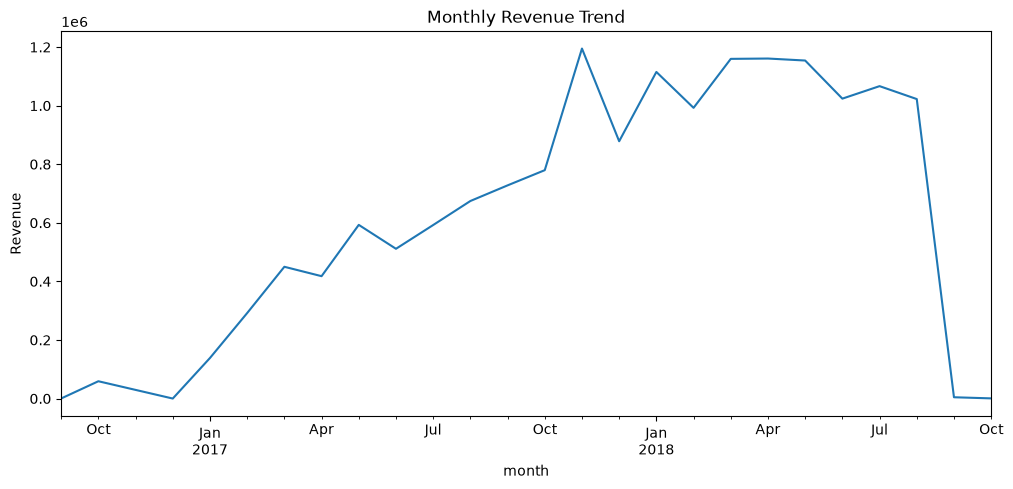

In [46]:
monthly_revenue.plot(
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.show()

# Executive Summary

## Customer Behavior
- Most orders are successfully delivered.
- Customer ratings are predominantly positive, indicating overall satisfaction.

## Product Performance
- A small number of product categories account for a significant share of total orders.
- Popular categories should be prioritized for inventory planning and promotions.

## Payment Behavior
- Credit cards are the preferred payment method.
- Installment-based purchases are common, reflecting consumer financing preferences.

## Revenue Trends
- Monthly revenue fluctuates over time, highlighting periods of stronger and weaker sales.
- Revenue analysis can guide seasonal marketing and inventory decisions.

## Logistics
- Delivery performance influences customer satisfaction.
- Reducing delivery times could further improve review scores.

## Geographic Insights
- Customer demand and seller activity are concentrated in specific Brazilian states, suggesting opportunities for regional expansion.

## Overall Conclusion
The Olist marketplace demonstrates strong operational performance, healthy customer engagement, and consistent transaction quality. The insights generated in this analysis can support decisions related to logistics, inventory management, customer experience, and revenue optimization.